# IMPORT LIBRARIES

In [1]:
# PLOTTING & DATA STUFF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
import joblib


# DIM REDUCTION
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from openTSNE import TSNE
from sklearn.manifold import Isomap
import umap

# OUTLIERS
from pyod.models.knn import KNN
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IsolationForest

# HELPERS
from utils import backup_dataframe, load_latest_backup


In [172]:
#!pip install openTSNE
#!pip install umap-learn
#!pip install pyod

# LOAD CSV

In [10]:
pd.set_option("display.max_colwidth", None)  # Show full content in columns
pd.set_option("display.max_rows", None)

In [11]:
df = pd.read_csv("dataset/train_pre_outlier.csv")

In [12]:
df.columns

Index(['Unnamed: 0', 'runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes',
       'isAdult', 'numRegions', 'castNumber', 'companiesNumber',
       'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal',
       'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy',
       'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family',
       'genre_Romance', 'genre_Short', 'genre_Unknown', 'sound_Unknown',
       'sound_dolby', 'sound_dolby_atmos', 'sound_dolby_digital',
       'sound_dolby_sr', 'sound_dolby_stereo', 'sound_dts', 'sound_mono',
       'sound_sdds', 'sound_silent', 'sound_stereo', 'continent_Africa',
       'continent_Antarctica', 'continent_Asia', 'continent_Australia',
       'continent_Europe', 'continent_North America', 'continent_Oceania',
       'continent_Other', 'continent_South America', 'release_decade',
       'word_count', 'award_ratio', 'total_multimedia', 'rating_category',
       'sentiment_Negative', 'sentiment_Neutral',

# FAST CHECK AND PROCESS

In [13]:
df.shape

(116539, 61)

In [14]:
df.head()

,Unnamed: 0,runtimeMinutes,criticReviewsTotal,canHaveEpisodes,isAdult,numRegions,castNumber,companiesNumber,averageRating,writerCredits,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,0,-0.500000,0.0,False,0,0.0,-0.3125,0.00,-2.176471,0.0,...,False,True,False,False,False,False,False,False,False,False
1,1,-0.557692,0.0,False,0,0.0,-0.0625,-0.25,-0.647059,0.0,...,False,False,False,False,False,False,False,False,True,False
2,2,0.134615,0.0,False,0,0.0,0.4375,2.25,0.117647,1.0,...,False,False,True,False,False,False,False,False,False,False
3,3,0.269231,0.0,False,0,0.0,-0.6875,-0.25,-2.117647,0.0,...,True,False,False,False,False,False,False,False,False,False
4,4,-0.615385,1.0,False,0,0.0,-0.5625,-0.25,-0.411765,0.0,...,False,True,False,False,False,False,False,False,False,False


In [15]:
df = df.drop(columns=["Unnamed: 0"])

In [16]:
df.columns

Index(['runtimeMinutes', 'criticReviewsTotal', 'canHaveEpisodes', 'isAdult',
       'numRegions', 'castNumber', 'companiesNumber', 'averageRating',
       'writerCredits', 'directorsCredits', 'quotesTotal', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime',
       'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Romance',
       'genre_Short', 'genre_Unknown', 'sound_Unknown', 'sound_dolby',
       'sound_dolby_atmos', 'sound_dolby_digital', 'sound_dolby_sr',
       'sound_dolby_stereo', 'sound_dts', 'sound_mono', 'sound_sdds',
       'sound_silent', 'sound_stereo', 'continent_Africa',
       'continent_Antarctica', 'continent_Asia', 'continent_Australia',
       'continent_Europe', 'continent_North America', 'continent_Oceania',
       'continent_Other', 'continent_South America', 'release_decade',
       'word_count', 'award_ratio', 'total_multimedia', 'rating_category',
       'sentiment_Negative', 'sentiment_Neutral', 'sentiment_Po

In [17]:
df.shape

(116539, 60)

In [18]:
numerical_vars_to_check = [
    "runtimeMinutes",
    "criticReviewsTotal",
    "numRegions",
    "ratingCount",
    "castNumber",
    "companiesNumber",
    "averageRating",
    "externalLinks",
    "writerCredits",
    "directorsCredits",
    "quotesTotal",
    "release_decade",
    "word_count",
    "award_ratio",
    "total_multimedia",
]


In [19]:
cat = list(set(df.columns) - set(numerical_vars_to_check))

In [20]:
df_num = df.drop(cat, axis=1)

In [21]:
X = df_num.values

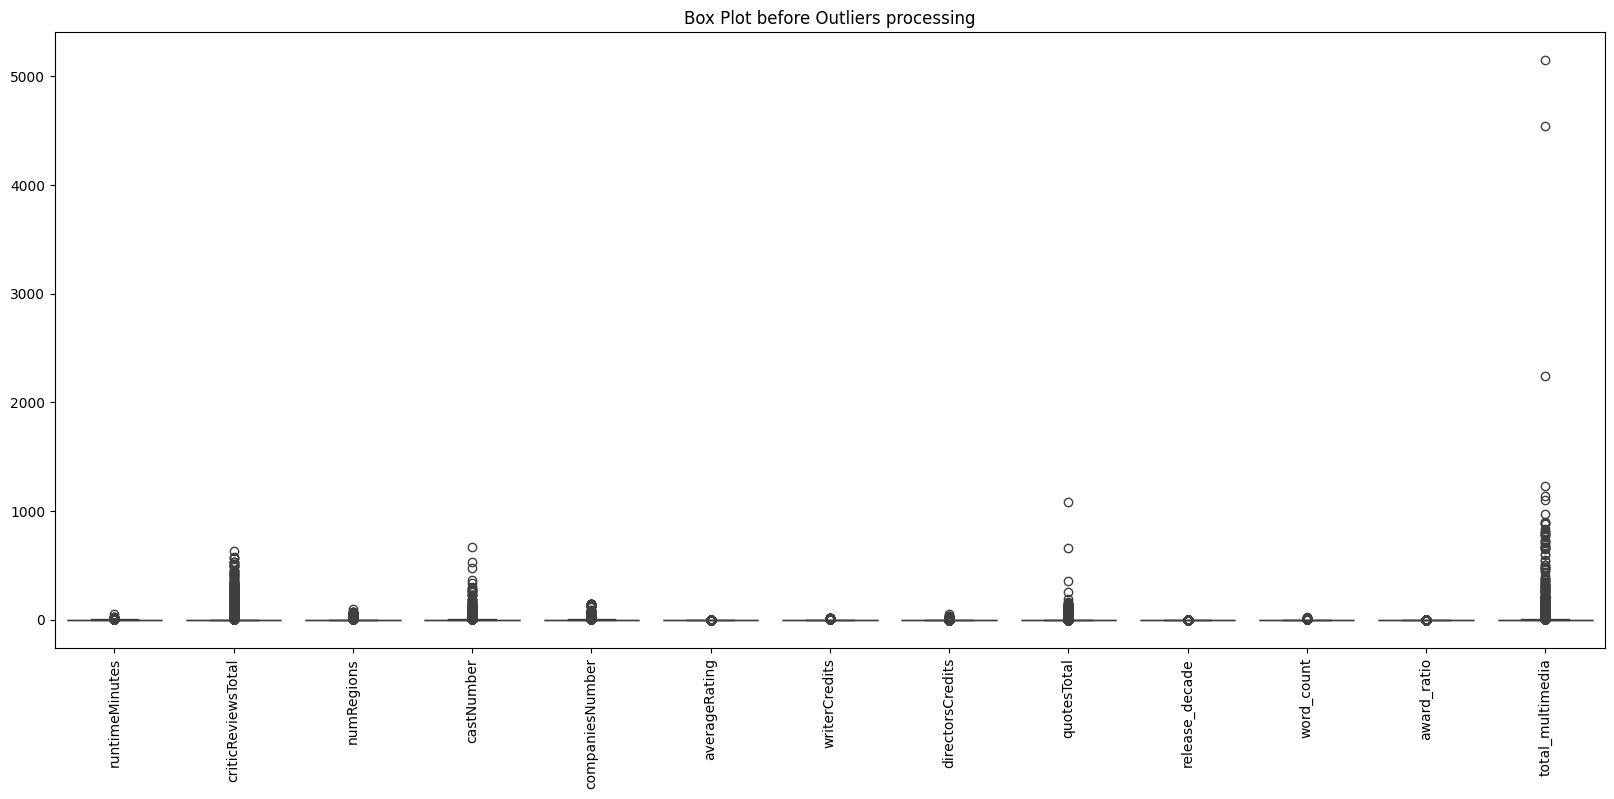

In [15]:
plt.figure(figsize=(20, 8))
sns.boxplot(df_num)
plt.xticks(rotation=90)
plt.title("Box Plot before Outliers processing")
plt.show()

# DIM REDUCTION

## PCA

In [15]:
pca = PCA(n_components=2)  # Scegli il numero di componenti principali desiderate
X_pca = pca.fit_transform(X)


/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_3284/2570865273.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap="muted", alpha=0.5, s=5)
/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_3284/2570865273.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


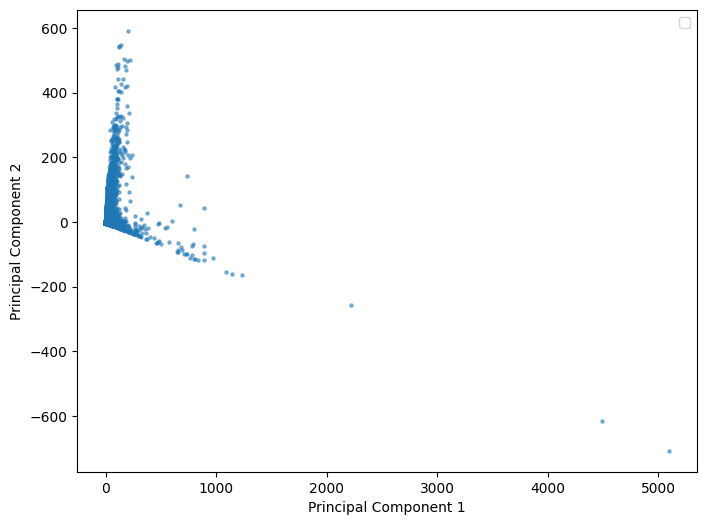

In [16]:
# Plot dei punti ridotti
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap="muted", alpha=0.5, s=5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [17]:
# Riduci la dimensionalità utilizzando PCA
pca = PCA(n_components=3)  # Scegli il numero di componenti principali desiderate
X_pca_3d = pca.fit_transform(X)

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


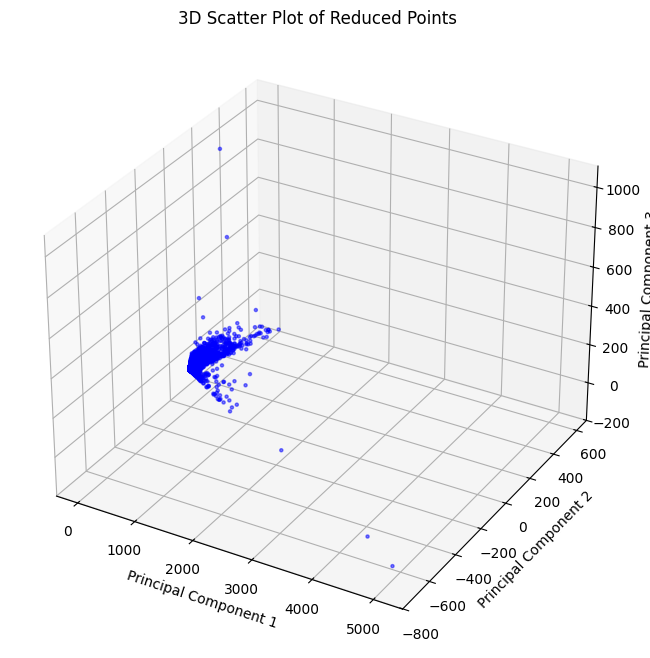

In [18]:
from mpl_toolkits.mplot3d import Axes3D

# 3D Scatter Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c="blue", alpha=0.5, s=5)

# Add labels
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.title("3D Scatter Plot of Reduced Points")
plt.show()

## T-SNE

In [19]:
#!pip install opentsne
# References: https://opentsne.readthedocs.io/en/stable/tsne_algorithm.html

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    initialization="pca",  # inizia con PCA embedding
    n_jobs=8,  # usa CPU parallele
    random_state=42,
)

X_array = X  
X_embedded = tsne.fit(X_array)  
plt.figure(figsize=(10, 7))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=5)
plt.title("openTSNE 2D visualization")
plt.grid(True)
plt.show()


KeyboardInterrupt: 

In [21]:
np.save(file="arrays/x_tsne.npy", arr=X_embedded)

In [16]:
X_tsne = np.load("arrays/X_tsne.npy")

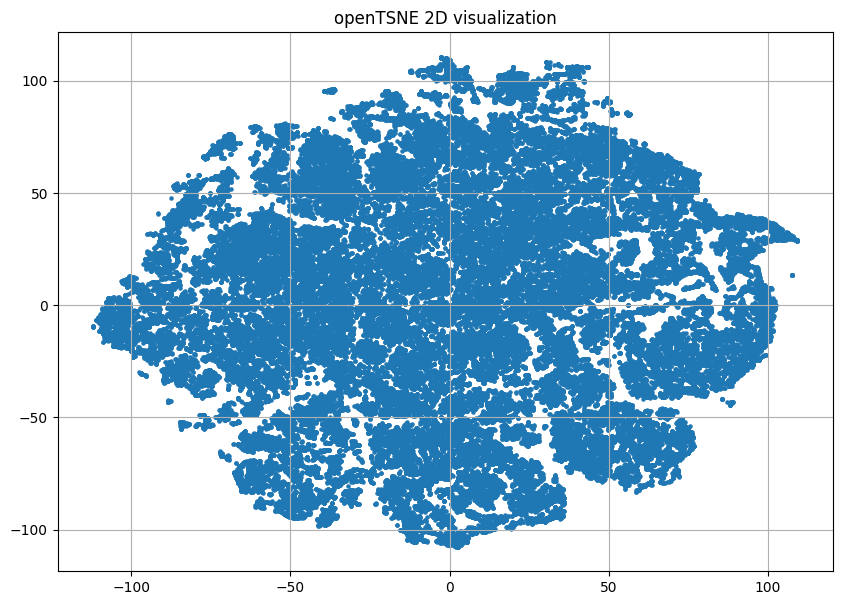

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5)
plt.title("openTSNE 2D visualization")
plt.grid(True)
plt.show()


## UMAP

In [23]:
#!pip install umap-learn

In [24]:
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)

/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/daviderizzello/Documents/Uni/DM2/Progetto/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [25]:
np.save("arrays/X_umap.npy", X_umap)

In [17]:
X_umap = np.load("arrays/X_umap.npy")

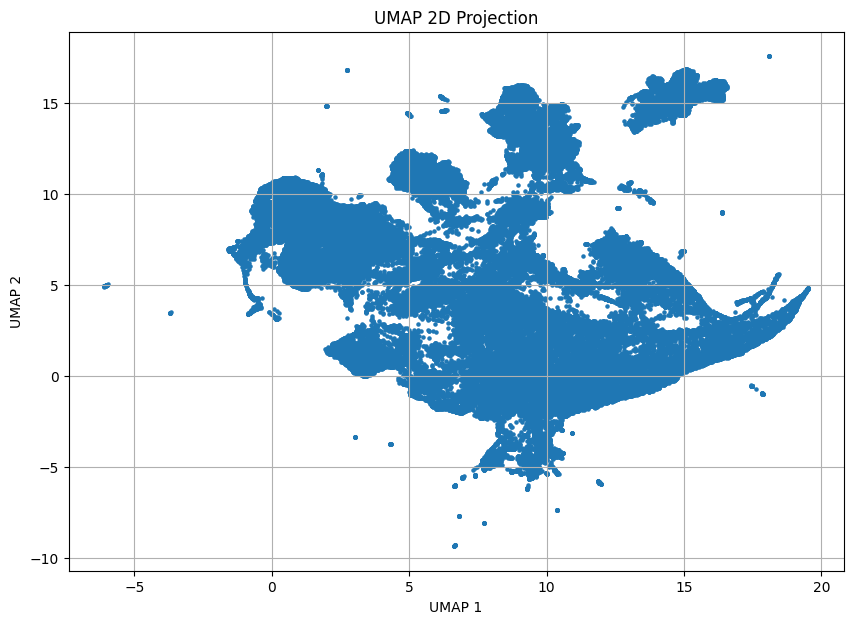

In [20]:
# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5)
plt.title("UMAP 2D Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

In [21]:
X_umap.shape

(116539, 2)

In [22]:
X_tsne.shape

(116539, 2)

# DISTANCE BASED-APPROACH

In [30]:
#!pip install pyod

In [ ]:
%time

knn_detector = KNN(contamination=0.01, method="mean")  # 1% outlier
knn_detector.fit(X)


CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 4.05 μs


KNN(algorithm='auto', contamination=0.01, leaf_size=30, method='mean',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [ ]:
%time
outliers = knn_detector.predict(X)
np.unique(outliers, return_counts=True)

CPU times: user 1 μs, sys: 0 ns, total: 1 μs
Wall time: 1.19 μs


(array([0, 1]), array([115753,    786]))

In [33]:
i = np.where(outliers == 1)  # when comparing arrays of integers
i

(array([   453,    835,    963,    990,    996,   1084,   1121,   1147,
          1239,   1333,   1558,   1598,   1651,   1716,   1900,   1928,
          1984,   2146,   2240,   2901,   3135,   3919,   4209,   4254,
          4598,   4726,   4733,   4899,   5162,   5425,   5469,   5471,
          5585,   5607,   5724,   5743,   5834,   6051,   6060,   6092,
          6300,   6311,   6337,   6401,   6460,   6555,   6719,   7031,
          7323,   7545,   7913,   8289,   8487,   8488,   8561,   8874,
          9459,   9548,  10035,  10291,  10449,  10557,  10568,  10945,
         10995,  11047,  11058,  11187,  11641,  12025,  12072,  12286,
         12573,  12638,  12640,  12696,  12764,  12775,  13007,  13044,
         13191,  13299,  13355,  13357,  13366,  13562,  13717,  13769,
         13789,  13851,  13894,  14114,  14335,  14619,  14702,  14801,
         14805,  14844,  15206,  15337,  15600,  15756,  15841,  16053,
         16067,  16218,  16247,  16310,  16343,  16359,  16384, 

In [ ]:
outlier_knn = np.where(outliers == 1)[0]

In [35]:
outliers_knn = knn_detector.labels_  # oppure se hai salvato predict

In [37]:
np.save("arrays/outlier_indices_knn.npy", outlier_knn)

In [2]:
outlier_knn = np.load("arrays/outlier_indices_knn.npy")

In [ ]:
outlier_knn_indices = np.where(outlier_knn == 1)[0]

IndexError: tuple index out of range

In [9]:
len(outlier_knn)

786

In [53]:
plt.hist(knn_detector.decision_scores_, bins=20)
plt.axvline(np.min(knn_detector.decision_scores_[np.where(outliers == 1)]), c="k")
plt.show()

NameError: name 'knn_detector' is not defined

In [58]:
palette = "dark"  # 'deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind'

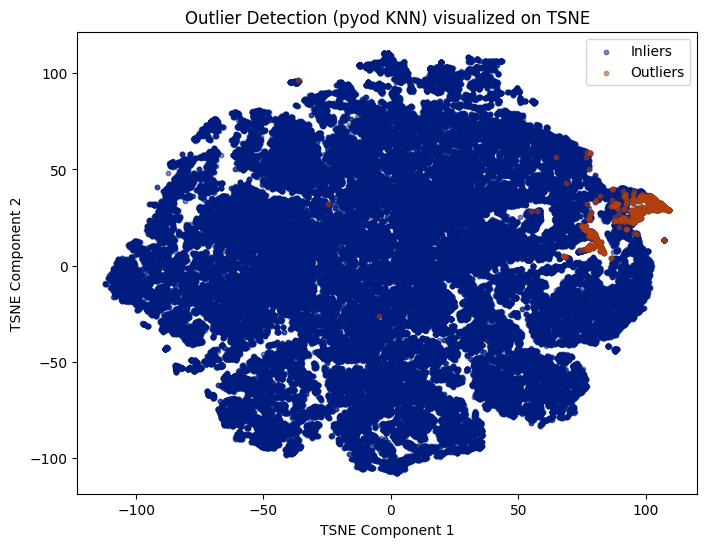

In [59]:
# TSNE plot
plt.figure(figsize=(8, 6))

# Plot inliers
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    label="Inliers",
    color=sns.color_palette(palette)[0],
    alpha=0.5,
    s=10,
)

# Plot outliers
plt.scatter(
    X_tsne[outlier_knn, 0],
    X_tsne[outlier_knn, 1],
    label="Outliers",
    color=sns.color_palette(palette)[1],
    alpha=0.5,
    s=10,
)

plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend()
plt.title("Outlier Detection (pyod KNN) visualized on TSNE")
plt.show()


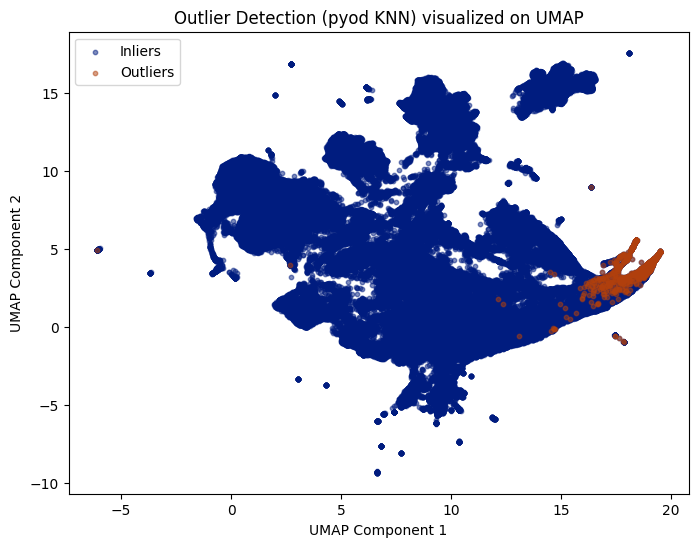

In [60]:
# TSNE plot
plt.figure(figsize=(8, 6))

# Plot inliers
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    label="Inliers",
    color=sns.color_palette(palette)[0],
    alpha=0.5,
    s=10,
)

# Plot outliers
plt.scatter(
    X_umap[outlier_knn, 0],
    X_umap[outlier_knn, 1],
    label="Outliers",
    color=sns.color_palette(palette)[1],
    alpha=0.5,
    s=10,
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend()
plt.title("Outlier Detection (pyod KNN) visualized on UMAP")
plt.show()


# ANGLE BASED-APPROACH

In [44]:
abod_detector = ABOD(contamination=0.01, n_neighbors=50, method="fast")
abod_detector.fit(X)

ABOD(contamination=0.01, method='fast', n_neighbors=50)

In [45]:
# Save the model
joblib.dump(abod_detector, "best_models/abod_model.joblib")


['best_models/abod_model.joblib']

In [23]:
abod_detector = joblib.load("best_models/abod_model.joblib")

In [24]:
outliers = abod_detector.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([115380,   1159]))

In [25]:
# outliers = abod_detector.labels_  # 0 = normale, 1 = outlier
scores = abod_detector.decision_scores_  # punteggio di anomalia continuo


In [26]:
outlier__abod = np.where(outliers == 1)[0]
print(len(outlier__abod))


1159


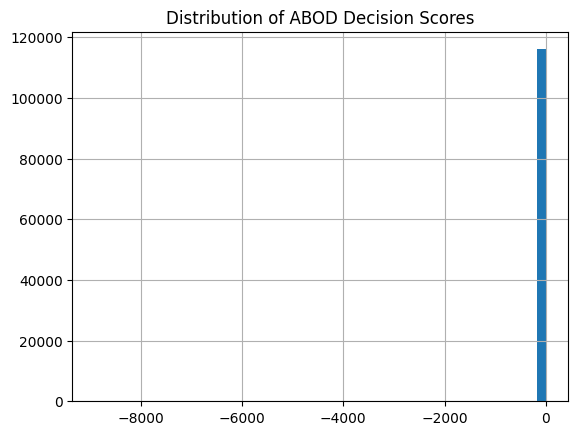

In [27]:
plt.hist(scores, bins=50)
plt.title("Distribution of ABOD Decision Scores")
plt.grid(True)
plt.show()

In [28]:
np.save("arrays/abod_model_prediction.npy", outliers)

In [29]:
outliers = np.load("arrays/abod_model_prediction.npy")

In [30]:
outliers_abod = abod_detector.labels_  # array 0/1
outlier_abod_indices = np.where(outliers_abod == 1)[0]

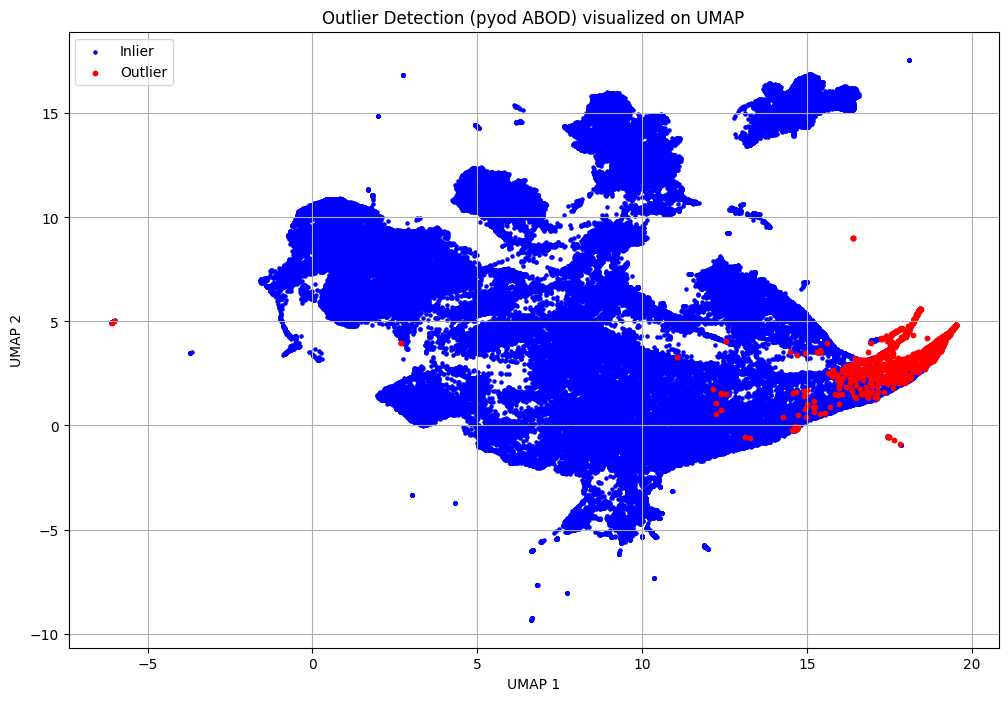

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_umap[abod_detector.labels_ == 0, 0],
    X_umap[abod_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Inlier",
)

# plot outliers
plt.scatter(
    X_umap[abod_detector.labels_ == 1, 0],
    X_umap[abod_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod ABOD) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


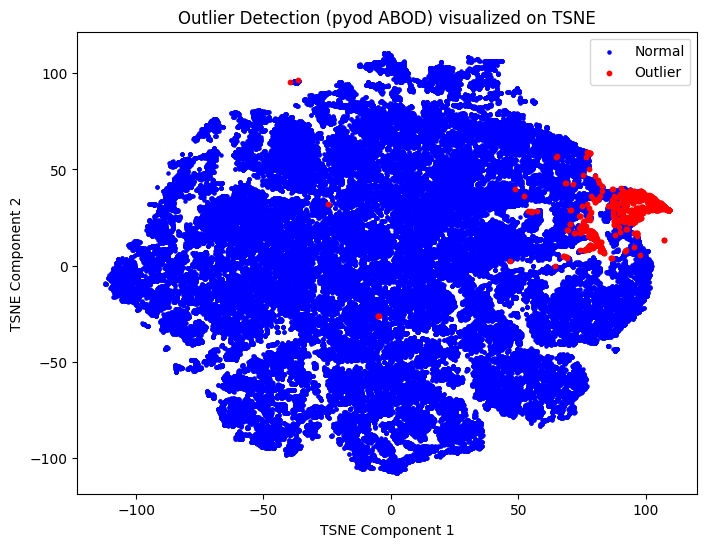

In [32]:
# TSNE plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[abod_detector.labels_ == 0, 0],
    X_tsne[abod_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Normal",
)

plt.scatter(
    X_tsne[abod_detector.labels_ == 1, 0],
    X_tsne[abod_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.xlabel("TSNE Component 1")
plt.ylabel("TSNE Component 2")
plt.legend()
plt.title("Outlier Detection (pyod ABOD) visualized on TSNE")
plt.show()


# DENSITY BASED-APPROACH

In [22]:
lof_detector = LOF(n_neighbors=10, contamination=0.01)
lof_detector.fit(X)

KeyboardInterrupt: 

In [ ]:
outliers = lof_detector.labels_  # 0 = normal, 1 = outlier
scores = lof_detector.decision_scores_  


In [35]:
outliers_lof = lof_detector.labels_  # array 0/1
outlier_lof_indices = np.where(outliers_lof == 1)[0]

In [36]:
np.unique(outliers, return_counts=True)

(array([0, 1]), array([115373,   1166]))

In [37]:
outlier_lof = np.where(outliers == 1)[0]

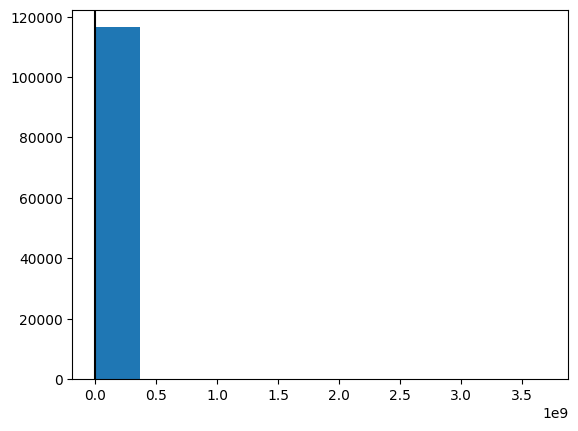

In [38]:
plt.hist(lof_detector.decision_scores_, bins=10)
plt.axvline(np.min(lof_detector.decision_scores_[np.where(outliers == 1)]), c="k")
plt.show()

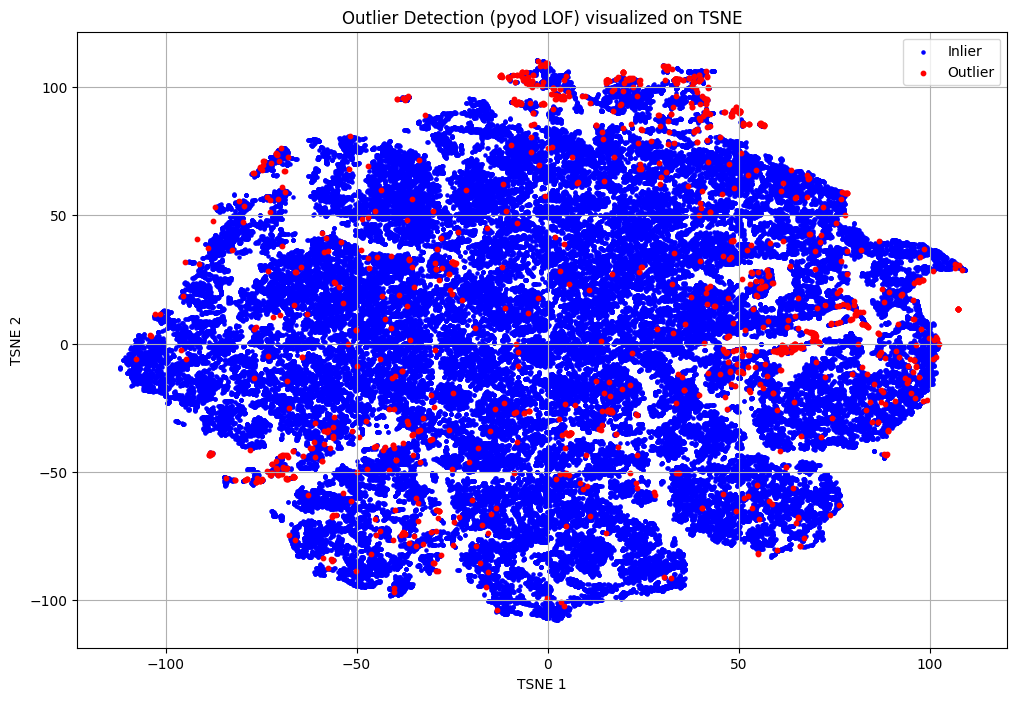

In [39]:
plt.figure(figsize=(12, 8))

plt.scatter(
    X_tsne[lof_detector.labels_ == 0, 0],
    X_tsne[lof_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Inlier",
)

plt.scatter(
    X_tsne[lof_detector.labels_ == 1, 0],
    X_tsne[lof_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod LOF) visualized on TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend()
plt.grid(True)
plt.show()


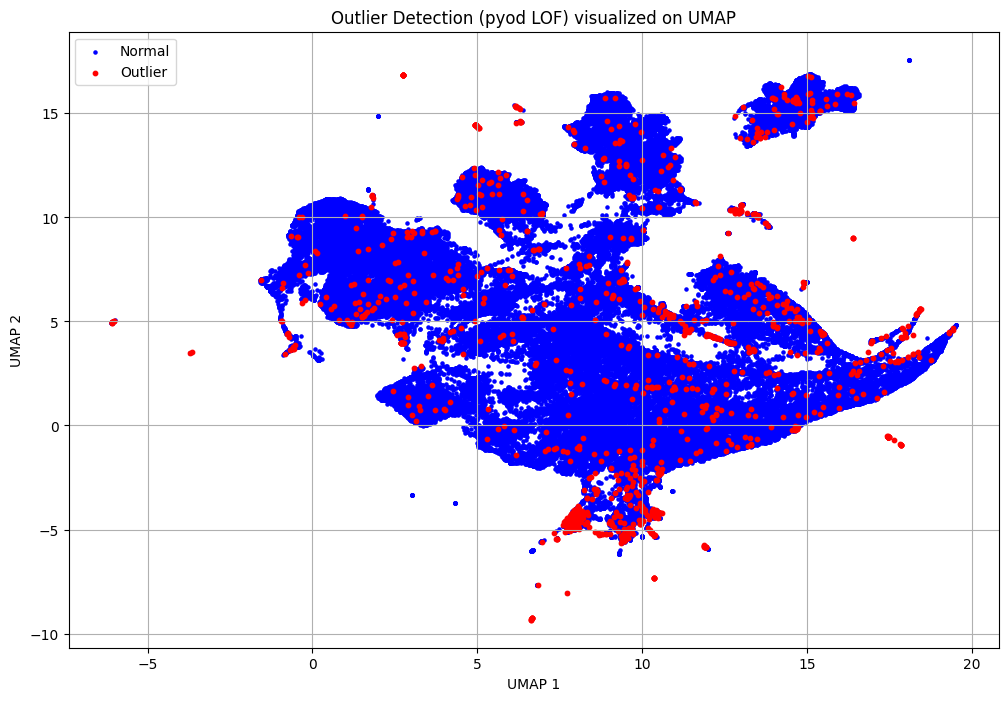

In [ ]:
plt.figure(figsize=(12, 8))


plt.scatter(
    X_umap[lof_detector.labels_ == 0, 0],
    X_umap[lof_detector.labels_ == 0, 1],
    color="blue",
    s=5,
    label="Normal",
)

# plot outliers
plt.scatter(
    X_umap[lof_detector.labels_ == 1, 0],
    X_umap[lof_detector.labels_ == 1, 1],
    color="red",
    s=10,
    label="Outlier",
)

plt.title("Outlier Detection (pyod LOF) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


# ISOFOREST

In [41]:
isoforest_detector = IsolationForest(contamination=0.01)
isoforest_detector.fit(X)

IsolationForest(contamination=0.01)

In [42]:
outliers = isoforest_detector.predict(X)
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([  1166, 115373]))

In [43]:
outlier_if = np.where(outliers == -1)[0]
print(len(outlier_if))


1166


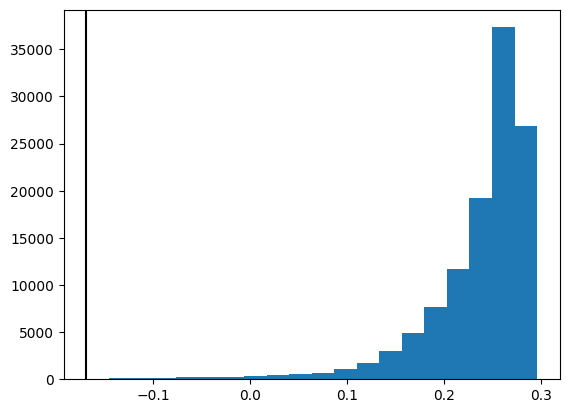

In [44]:
plt.hist(isoforest_detector.decision_function(X), bins=20)
plt.axvline(
    np.min(isoforest_detector.decision_function(X)[np.where(outliers == -1)]), c="k"
)
plt.show()

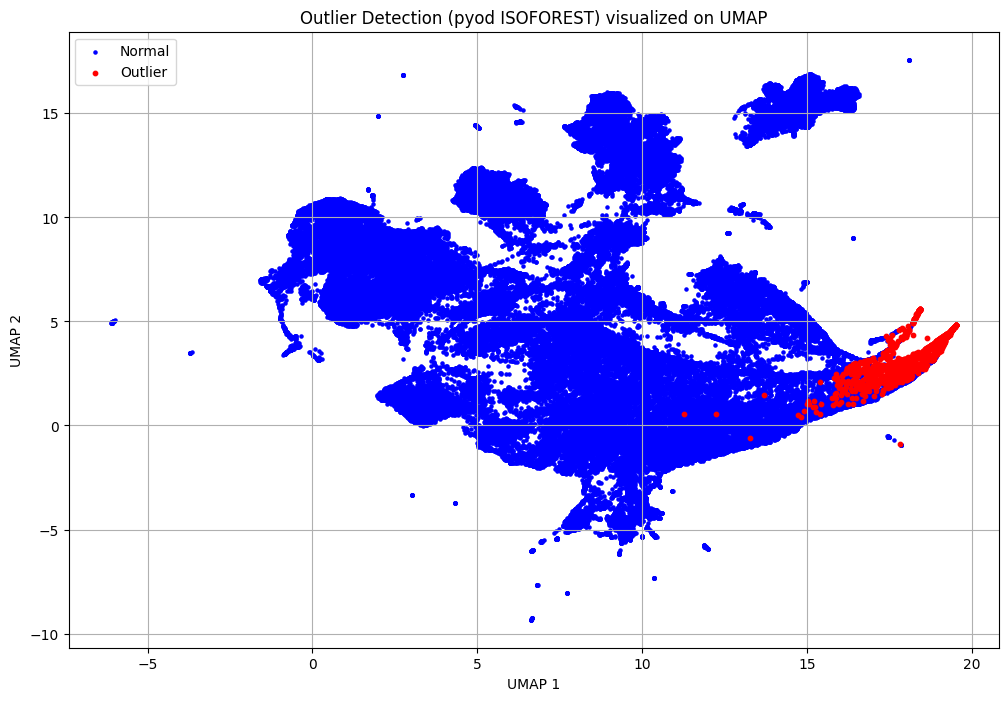

In [45]:
plt.figure(figsize=(12, 8))

# Disegna i punti normali
plt.scatter(X_umap[:, 0], X_umap[:, 1], color="blue", s=5, label="Normal")

# Disegna i punti anomali
plt.scatter(
    X_umap[outlier_if, 0], X_umap[outlier_if, 1], color="red", s=10, label="Outlier"
)

plt.title("Outlier Detection (pyod ISOFOREST) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()

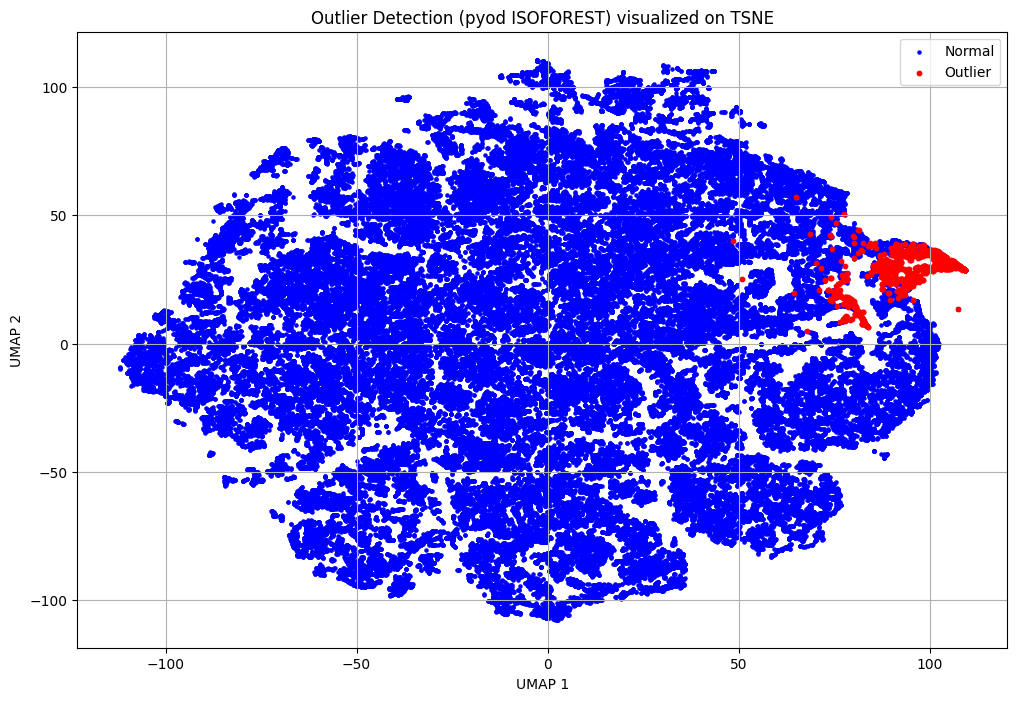

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], color="blue", s=5, label="Normal")

# plot outliers
plt.scatter(
    X_tsne[outlier_if, 0], X_tsne[outlier_if, 1], color="red", s=10, label="Outlier"
)

plt.title("Outlier Detection (pyod ISOFOREST) visualized on TSNE")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()

# SUM UP

In [ ]:
# intesection (KNN + ABOD + LOF + Isolation Forest)
outliers_common_all = np.intersect1d(
    np.intersect1d(
        np.intersect1d(outlier_knn, outlier_abod_indices), outlier_lof_indices
    ),
    outlier_if,
)

# pairs interesection
knn_abod = np.intersect1d(outlier_knn, outlier_abod_indices)
knn_lof = np.intersect1d(outlier_knn, outlier_lof_indices)
knn_if = np.intersect1d(outlier_knn, outlier_if)
abod_lof = np.intersect1d(outlier_abod_indices, outlier_lof_indices)
abod_if = np.intersect1d(outlier_abod_indices, outlier_if)
lof_if = np.intersect1d(outlier_lof_indices, outlier_if)

# unique outliers by each method
only_knn = np.setdiff1d(
    outlier_knn,
    np.union1d(np.union1d(outlier_abod_indices, outlier_lof_indices), outlier_if),
)
only_abod = np.setdiff1d(
    outlier_abod_indices,
    np.union1d(np.union1d(outlier_knn, outlier_lof_indices), outlier_if),
)
only_lof = np.setdiff1d(
    outlier_lof_indices,
    np.union1d(np.union1d(outlier_knn, outlier_abod_indices), outlier_if),
)
only_if = np.setdiff1d(
    outlier_if,
    np.union1d(np.union1d(outlier_knn, outlier_abod_indices), outlier_lof_indices),
)

# --- Print Results ---

print(
    f"🔵 Common outliers between the 4 methods (KNN, ABOD, LOF, Isolation Forest): {len(outliers_common_all)}"
)
print(f"🟠 Common outliers KNN-ABOD: {len(knn_abod)}")
print(f"🟠 Common outliers KNN-LOF: {len(knn_lof)}")
print(f"🟠 Common outliers KNN-IF: {len(knn_if)}")
print(f"🟠 Common outliers ABOD-LOF: {len(abod_lof)}")
print(f"🟠 Common outliers ABOD-IF: {len(abod_if)}")
print(f"🟠 Common outliers LOF-IF: {len(lof_if)}")

print(f"🔴 Unique outliers found only by KNN: {len(only_knn)}")
print(f"🔴 Unique outliers found only by ABOD: {len(only_abod)}")
print(f"🔴 Unique outliers found only by LOF: {len(only_lof)}")
print(f"🔴 Unique outliers found only by Isolation Forest: {len(only_if)}")


🔵 Common outliers between the 4 methods (KNN, ABOD, LOF, Isolation Forest): 48
🟠 Common outliers KNN-ABOD: 785
🟠 Common outliers KNN-LOF: 76
🟠 Common outliers KNN-IF: 653
🟠 Common outliers ABOD-LOF: 100
🟠 Common outliers ABOD-IF: 875
🟠 Common outliers LOF-IF: 53
🔴 Unique outliers found only by KNN: 0
🔴 Unique outliers found only by ABOD: 137
🔴 Unique outliers found only by LOF: 1063
🔴 Unique outliers found only by Isolation Forest: 289


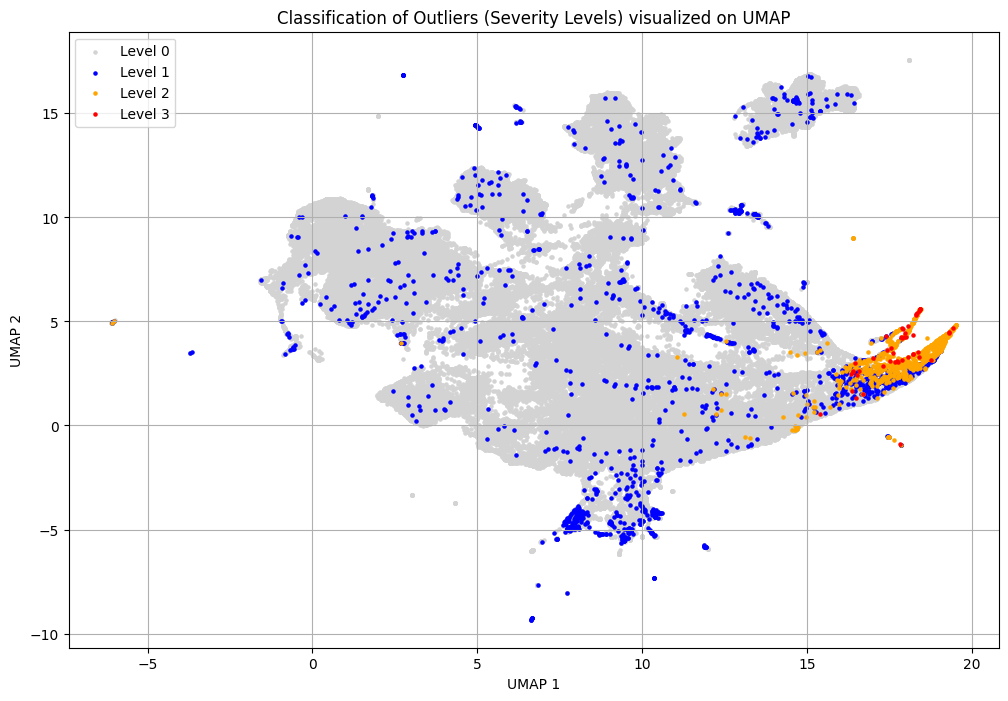

In [64]:
n_samples = X.shape[0]

outlier_level = np.zeros(n_samples)

# Hard Outliers (4 up)
outlier_level[outliers_common_all] = 3

# Moderate Outliers ( 2 or 3 methos)
# (every intersection 2 by 2, without the 4 ones)
moderate_outliers = np.unique(
    np.concatenate((knn_abod, knn_lof, knn_if, abod_lof, abod_if, lof_if))
)

# remove hard ones
moderate_outliers = np.setdiff1d(moderate_outliers, outliers_common_all)

outlier_level[moderate_outliers] = 2

# Weak Outliers (found only by 1 method)
weak_outliers = np.unique(np.concatenate((only_knn, only_abod, only_lof, only_if)))
outlier_level[weak_outliers] = 1

# Normal stays to 0

# 3. visualize on UMAP
plt.figure(figsize=(12, 8))

# Palette colori: 0 = grigio, 1 = blu, 2 = arancione, 3 = rosso
colors = {0: "lightgray", 1: "blue", 2: "orange", 3: "red"}

for level in [0, 1, 2, 3]:
    mask = outlier_level == level
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        color=colors[level],
        s=5,
        label=f"Level {level}",
    )

plt.title("Classification of Outliers (Severity Levels) visualized on UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()


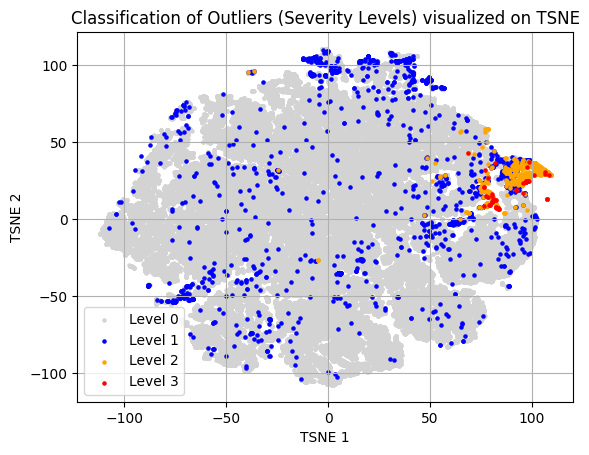

In [65]:
for level in [0, 1, 2, 3]:
    mask = outlier_level == level
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        color=colors[level],
        s=5,
        label=f"Level {level}",
    )

plt.title("Classification of Outliers (Severity Levels) visualized on TSNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
df_outlier_info = pd.DataFrame(
    {
        "UMAP_1": X_umap[:, 0],
        "UMAP_2": X_umap[:, 1],
        "Outlier_Level": outlier_level.astype(int),
    }
)

# Salva
df_outlier_info.to_csv("dataset/outlier_levels_umap.csv", index=False)


In [67]:
mask_keep = (outlier_level == 0) | (outlier_level == 1)

df_cleaned = df[mask_keep].reset_index(drop=True)

print(f"Cleaned dataset shape: {df_cleaned.shape}")


Cleaned dataset shape: (115507, 60)


In [68]:
print(df.shape[0] - df_cleaned.shape[0])

1032


In [69]:
df_num_cleaned = df_cleaned.drop(cat, axis=1)

/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_29774/993210491.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)
/var/folders/9v/f8wr4b9x0zdf_z5f4n5y_dr80000gn/T/ipykernel_29774/993210491.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


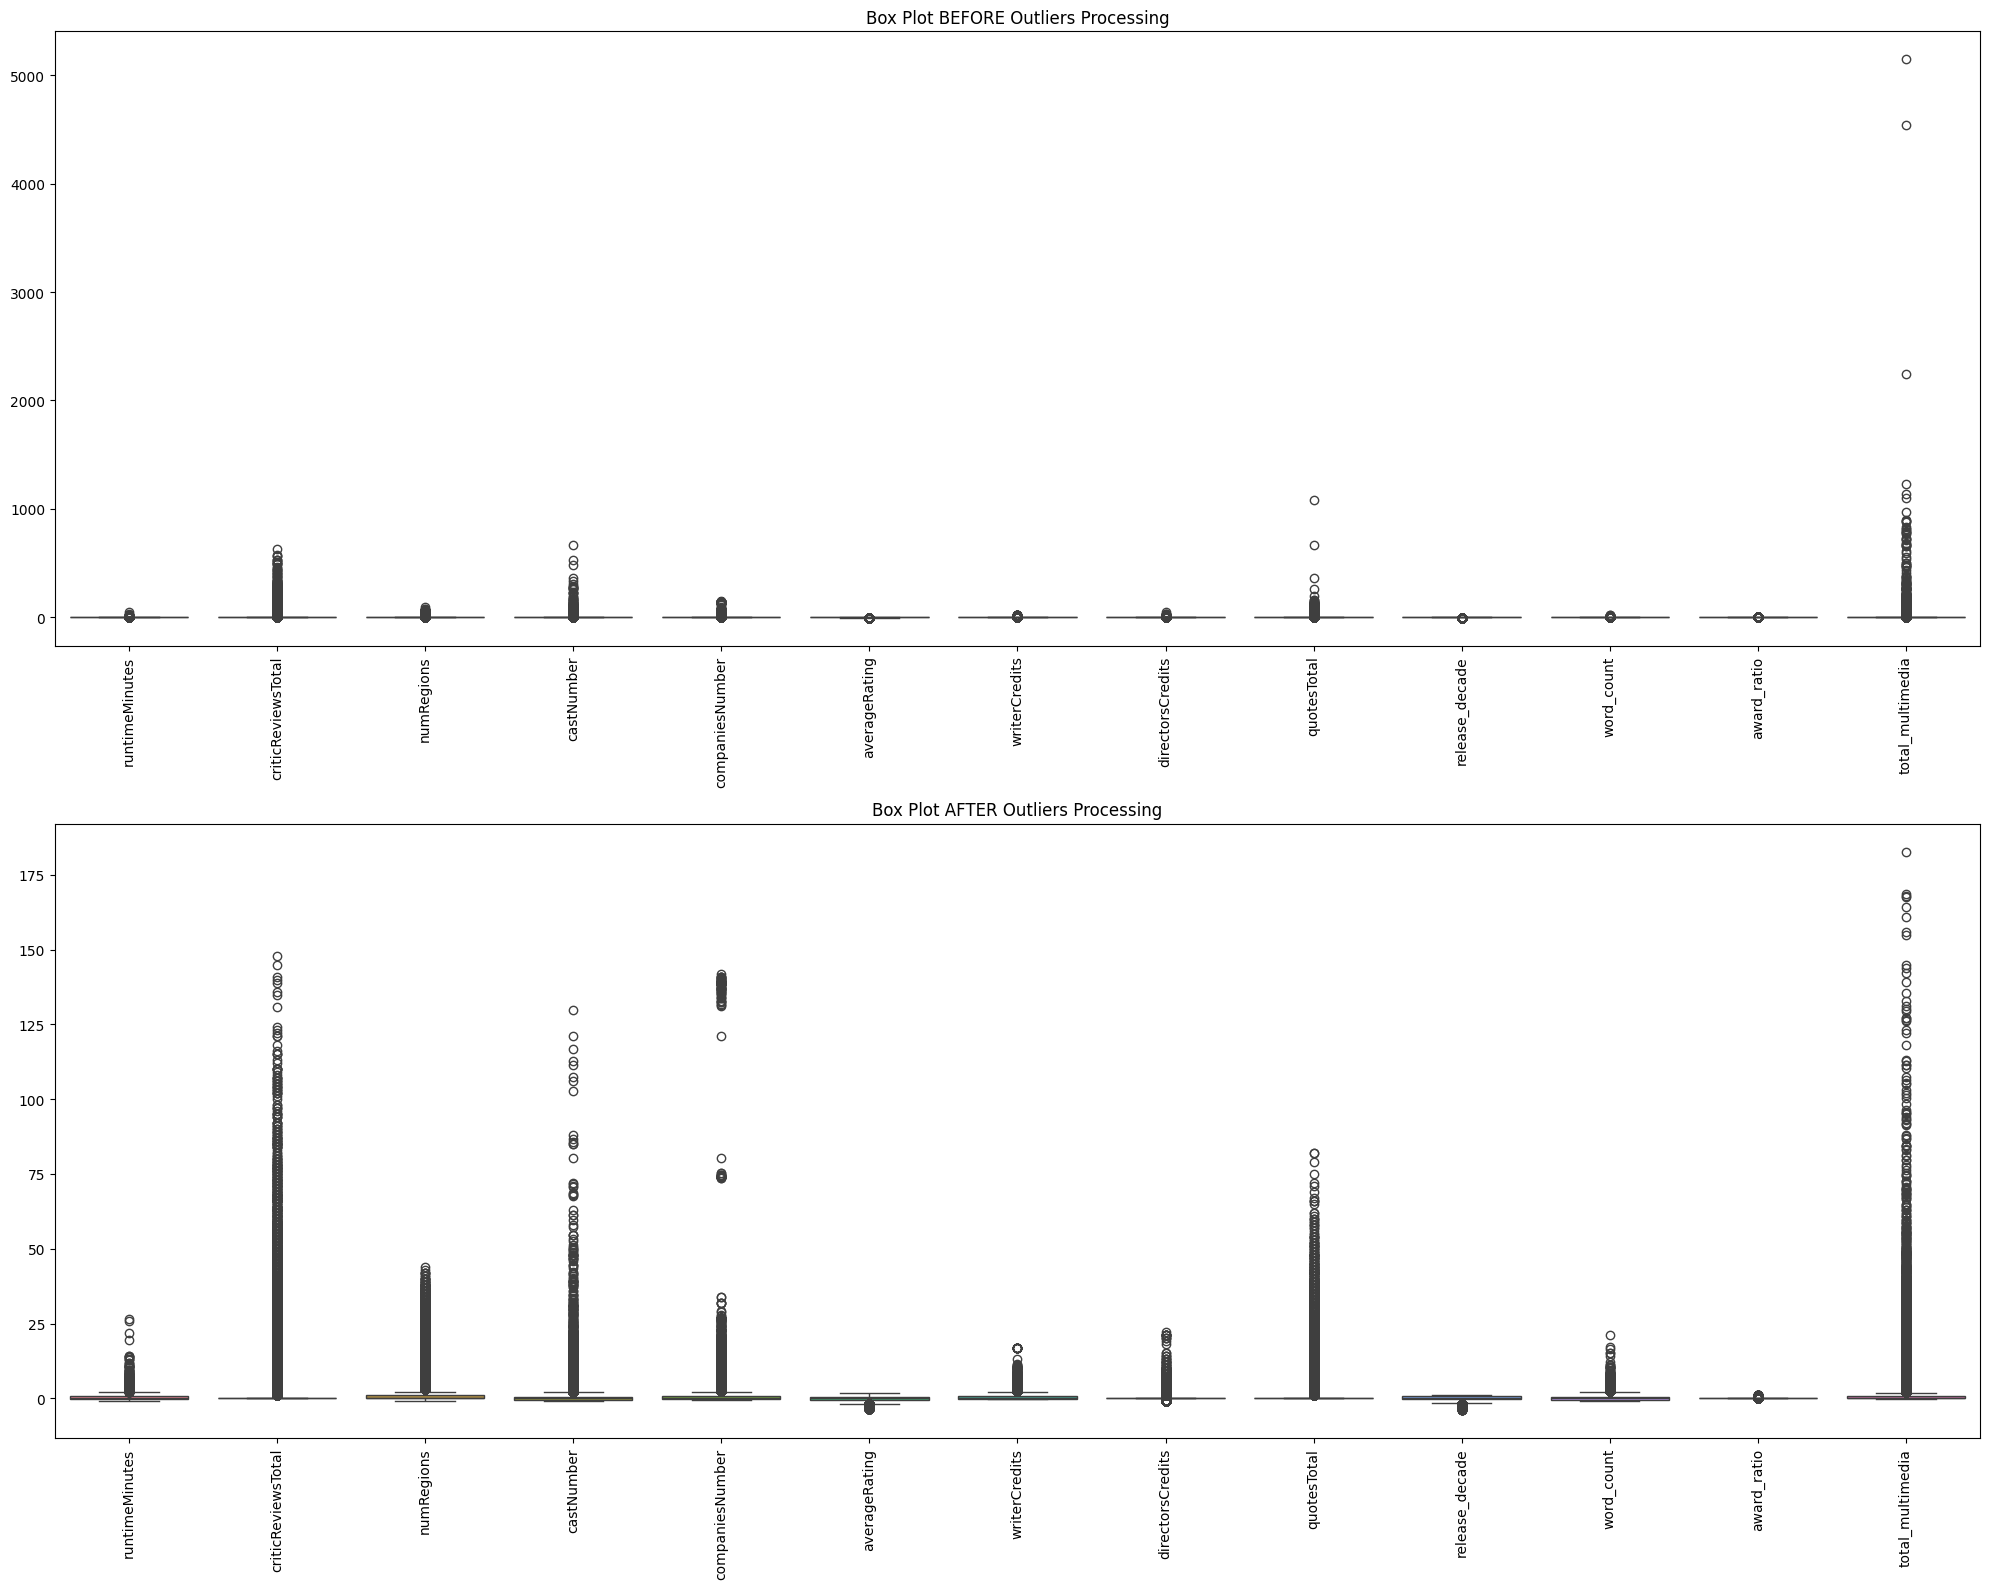

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(20, 16))  # 2 rows, 1 column

sns.boxplot(data=df_num, ax=axes[0])
axes[0].set_title("Box Plot BEFORE Outliers Processing")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)


sns.boxplot(data=df_num_cleaned, ax=axes[1])
axes[1].set_title("Box Plot AFTER Outliers Processing")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)


plt.tight_layout()
plt.show()


In [71]:
df_cleaned.to_csv("dataset/train_post_outlier.csv")

In [72]:
df = pd.read_csv("dataset/train_post_outlier.csv")